# Tratamiento automático de fotos de localizaciones

**Prueba de concepto** — selección automática de fotos representativas y descripción de una localización a partir de su reportaje fotográfico, usando Azure AI Foundry.

## Objetivo

Cuando se ficha una localización para un shooting (moda / publicidad), se genera un reportaje fotográfico con decenas o cientos de fotos, muchas de ellas muy similares entre sí (mismo rincón, distintos ángulos o encuadres). Revisar ese material a mano para preparar un dossier de presentación es lento y repetitivo.

Este notebook automatiza dos tareas sobre una carpeta de fotos de una localización:

1. **Selección de fotos representativas**: de todo el reportaje, identificar automáticamente los distintos "ambientes" o rincones visualmente diferenciados de la localización, y quedarnos con una foto representativa de cada uno — descartando duplicados y casi-duplicados.
2. **Descripción automática**: a partir de esas fotos representativas, generar una descripción textual de la localización orientada a un dossier de cliente (estilo, luz, ambientes, uso recomendado).

## Cómo funciona (resumen técnico)

| Paso | Qué hace | Servicio |
|---|---|---|
| 1. Ingesta | Carga las fotos de la carpeta de la localización | Local (Pillow) |
| 2. Embeddings | Convierte cada foto en un vector numérico (1024 dimensiones) que representa su contenido visual | Azure AI Vision — *multimodal embeddings v4.0* |
| 3. Deduplicación | Compara los vectores por similitud coseno; descarta fotos casi idénticas a otra ya conservada | Local (numpy) |
| 4. Clustering dinámico | Agrupa las fotos restantes por similitud visual, sin fijar de antemano cuántos grupos habrá | Local (scikit-learn, HDBSCAN) |
| 5. Selección de representante | De cada grupo, elige la foto más "central" (el *medoid*) | Local (numpy) |
| 6. Descripción automática | Redacta una descripción de la localización a partir de las fotos representativas | Azure OpenAI — *gpt-4o (visión)* |

Solo los pasos 2 y 6 llaman a Azure; el resto es procesamiento local, por lo que se puede ejecutar tantas veces como haga falta sin coste adicional una vez calculados los embeddings (se cachean en disco).


## 1. Configuración

Cargamos las credenciales de Azure desde el fichero `.env` y las librerías necesarias.

In [83]:
import base64
import io
import json
import os
from pathlib import Path

import numpy as np
import requests
from dotenv import load_dotenv
from PIL import Image, ImageOps
from sklearn.cluster import HDBSCAN

# La raíz del proyecto es la carpeta padre de "Localizaciones" (donde vive el notebook)
PROJECT_ROOT = Path.cwd().parent
load_dotenv(PROJECT_ROOT / ".env")

AZURE_AI_KEY = os.environ["AZURE_AI_KEY"]
VISION_ENDPOINT = os.environ["AZURE_VISION_ENDPOINT"].rstrip("/")
VISION_API_VERSION = os.environ["AZURE_VISION_API_VERSION"]
VISION_MODEL_VERSION = os.environ["AZURE_VISION_MODEL_VERSION"]
OPENAI_ENDPOINT = os.environ["AZURE_OPENAI_ENDPOINT"].rstrip("/")
OPENAI_DEPLOYMENT = os.environ["AZURE_OPENAI_DEPLOYMENT"]
OPENAI_API_VERSION = os.environ["AZURE_OPENAI_API_VERSION"]

print("Configuración cargada correctamente.")

Configuración cargada correctamente.


### 1.1 Seguimiento de uso y coste

Azure factura estos dos servicios de forma distinta:
- **Azure Vision** (embeddings): por **transacción** (por imagen procesada), no por token.
- **Azure OpenAI** (gpt-4o): por **token**, con tarifas distintas de entrada y de salida.

Cada celda que llama a Azure registra su llamada en `usage_log` e imprime su coste estimado. Los precios de abajo son **placeholders**: rellénalos con tu tarifa real (Azure Pricing calculator o tu factura) antes de fiarte de las cifras en €/$ — el número de tokens/imágenes sí es exacto siempre, venga de la API.

In [84]:
# --- Precios: AJUSTA a tu tarifa real antes de fiarte del coste en €/$ ---
PRICE_PER_1K_VISION_TRANSACTIONS = 0.1  # coste por cada 1000 imágenes vectorizadas
PRICE_PER_1M_INPUT_TOKENS = 1.1  # coste por cada 1000000 tokens de entrada (gpt-4o)
PRICE_PER_1M_OUTPUT_TOKENS = 4.4  # coste por cada 1000000 tokens de salida (gpt-4o)

usage_log = []  # cada llamada a Azure añade aquí un registro, para el resumen final


def log_vision_call() -> None:
    usage_log.append({"service": "vision", "images": 1})


def log_openai_call(step: str, usage: dict) -> None:
    prompt_tokens = usage.get("prompt_tokens", 0)
    completion_tokens = usage.get("completion_tokens", 0)
    cost = (prompt_tokens / 1000000 * PRICE_PER_1M_INPUT_TOKENS) + (
        completion_tokens / 1000000 * PRICE_PER_1M_OUTPUT_TOKENS
    )
    usage_log.append(
        {
            "service": "openai",
            "step": step,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "cost": cost,
        }
    )
    print(f"    [{step}] {prompt_tokens} tokens entrada + {completion_tokens} salida -> ${cost:.4f}")


def usage_summary() -> None:
    """Resumen agregado de todas las llamadas a Azure registradas hasta ahora en este notebook."""
    vision_calls = [r for r in usage_log if r["service"] == "vision"]
    openai_calls = [r for r in usage_log if r["service"] == "openai"]

    n_images = len(vision_calls)
    vision_cost = n_images / 1000 * PRICE_PER_1K_VISION_TRANSACTIONS

    input_tokens = sum(r["prompt_tokens"] for r in openai_calls)
    output_tokens = sum(r["completion_tokens"] for r in openai_calls)
    openai_cost = sum(r["cost"] for r in openai_calls)

    print(f"Azure Vision  — {n_images} imágenes vectorizadas -> ${vision_cost:.4f}")
    print(
        f"Azure OpenAI  — {len(openai_calls)} llamadas, {input_tokens} tokens entrada "
        f"+ {output_tokens} tokens salida -> ${openai_cost:.4f}"
    )
    print(f"TOTAL estimado: ${vision_cost + openai_cost:.4f}")
    if PRICE_PER_1K_VISION_TRANSACTIONS == PRICE_PER_1K_INPUT_TOKENS == PRICE_PER_1K_OUTPUT_TOKENS == 0.0:
        print("\n(Precios sin configurar — rellena las constantes PRICE_PER_1K_* arriba con tu tarifa real.)")


print("Seguimiento de uso inicializado.")

Seguimiento de uso inicializado.


## 2. Selección de la localización y carga de fotos

Cada localización es una subcarpeta dentro de `Localizaciones/`. Para procesar una localización distinta, basta con cambiar `LOCATION_NAME` por el nombre de otra carpeta.

Definimos también `load_normalized`, que abre una foto, corrige su orientación (los metadatos EXIF de las cámaras a veces la giran) y la reescala a un tamaño máximo manejable — esta misma función se reutiliza en el resto del notebook, tanto para visualizar como para preparar las fotos antes de enviarlas a Azure. Las fotos originales no se modifican en disco.

In [85]:
# --- Elige aquí la localización a procesar (nombre de una subcarpeta de "Localizaciones") ---
LOCATION_NAME = "Teresitas Road"

LOCATION_DIR = PROJECT_ROOT / "Localizaciones" / LOCATION_NAME
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
MAX_SIZE = (768, 768)  # tamaño máximo tras normalizar, se conserva el ratio de aspecto

image_paths = sorted(
    p for p in LOCATION_DIR.iterdir() if p.suffix.lower() in IMAGE_EXTENSIONS
)
print(f'{len(image_paths)} fotos encontradas en "{LOCATION_NAME}"')


def load_normalized(path: Path) -> Image.Image:
    """Abre una foto, corrige su orientación EXIF y la reescala a MAX_SIZE."""
    img = Image.open(path)
    img = ImageOps.exif_transpose(img).convert("RGB")
    img.thumbnail(MAX_SIZE)
    return img

81 fotos encontradas en "Teresitas Road"


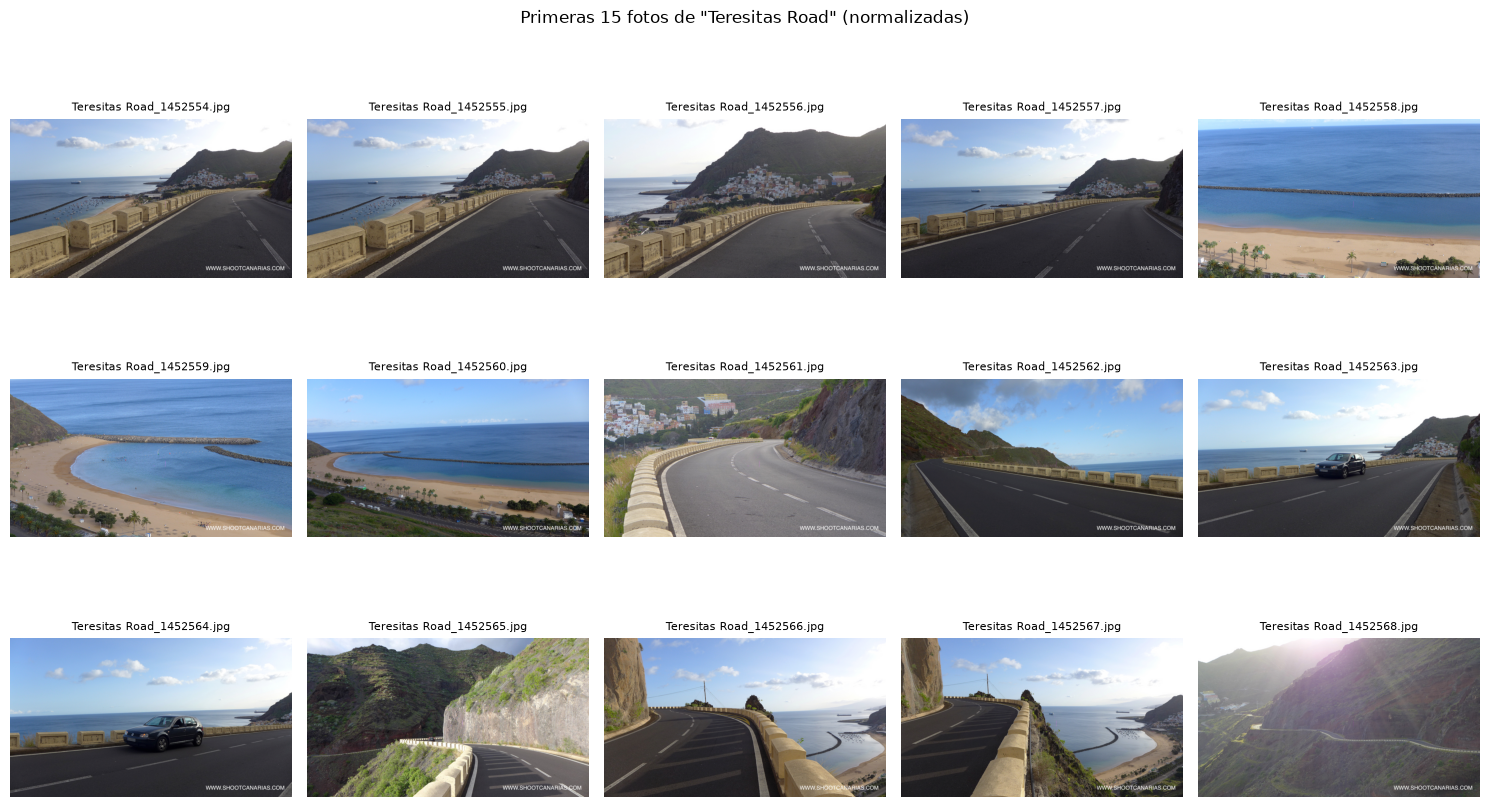

In [86]:
import matplotlib.pyplot as plt

N_COLS, N_ROWS = 5, 3
preview_paths = image_paths[: N_COLS * N_ROWS]

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(N_COLS * 3, N_ROWS * 3))

for ax, path in zip(axes.flat, preview_paths):
    ax.imshow(load_normalized(path))
    ax.set_title(path.name, fontsize=8)
    ax.axis("off")

# Si hay menos de 15 fotos, apagamos los huecos sobrantes de la rejilla
for ax in axes.flat[len(preview_paths):]:
    ax.axis("off")

fig.suptitle(f'Primeras {len(preview_paths)} fotos de "{LOCATION_NAME}" (normalizadas)')
plt.tight_layout()
plt.show()

## 3. Generación de embeddings de imagen

Un *embedding* es un vector numérico que resume el contenido visual de una foto: dos fotos parecidas (mismo encuadre, mismo rincón) tienen vectores cercanos entre sí, y fotos distintas tienen vectores alejados. Es la base tanto de la deduplicación como del clustering de los siguientes pasos.

Usamos el modelo de **Azure AI Vision — multimodal embeddings v4.0**, disponible directamente en el recurso Foundry del proyecto (`retrieval:vectorizeImage`), que devuelve un vector de 1024 dimensiones por imagen.

Como esta llamada tiene coste y las fotos de una localización no cambian entre ejecuciones, **cacheamos los vectores en disco** (`.cache/embeddings/<localización>.json`). Si el notebook se vuelve a ejecutar, solo se vectorizan las fotos nuevas.

In [87]:
def vectorize_image(img: Image.Image) -> np.ndarray:
    """Envía una foto ya normalizada a Azure AI Vision y devuelve su embedding (1024-d)."""
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=90)

    url = f"{VISION_ENDPOINT}/computervision/retrieval:vectorizeImage"
    params = {"api-version": VISION_API_VERSION, "model-version": VISION_MODEL_VERSION}
    headers = {"Ocp-Apim-Subscription-Key": AZURE_AI_KEY, "Content-Type": "application/octet-stream"}

    resp = requests.post(url, params=params, headers=headers, data=buf.getvalue())
    resp.raise_for_status()
    log_vision_call()
    return np.array(resp.json()["vector"], dtype=np.float32)

In [88]:
from tqdm import tqdm

cache_path = PROJECT_ROOT / ".cache" / "embeddings" / f"{LOCATION_NAME}.json"
cache_path.parent.mkdir(parents=True, exist_ok=True)
cache = json.loads(cache_path.read_text()) if cache_path.exists() else {}

embeddings = {}
n_new = 0
for path in tqdm(image_paths, desc="Vectorizando fotos"):
    if path.name in cache:
        embeddings[path.name] = np.array(cache[path.name], dtype=np.float32)
    else:
        vec = vectorize_image(load_normalized(path))
        embeddings[path.name] = vec
        cache[path.name] = vec.tolist()
        n_new += 1

cache_path.write_text(json.dumps(cache))
vision_cost = n_new / 1000 * PRICE_PER_1K_VISION_TRANSACTIONS
print(
    f"{len(embeddings)} embeddings listos ({n_new} nuevos, {len(embeddings) - n_new} desde cache) "
    f"-> ${vision_cost:.4f}"
)

Vectorizando fotos: 100%|██████████| 81/81 [00:47<00:00,  1.70it/s]

81 embeddings listos (81 nuevos, 0 desde cache) -> $0.0081


## 4. Deduplicación (fotos casi idénticas)

Comparamos cada par de embeddings mediante **similitud coseno**: cuanto más cercana a 1, más parecidas son dos fotos visualmente. Recorremos las fotos en orden y, si una es casi idéntica a otra que ya hemos conservado, la descartamos.

`DEDUP_THRESHOLD` es el umbral a partir del cual dos fotos se consideran "la misma" — 0.97 es un punto de partida conservador (solo descarta fotos muy repetidas: mismo encuadre, ráfagas). Es el primer parámetro que tiene sentido ajustar si el resultado incluye demasiadas o demasiado pocas fotos.

In [89]:
DEDUP_THRESHOLD = 0.95  # similitud coseno a partir de la cual dos fotos se consideran "la misma"

names = list(embeddings.keys())
X = np.stack([embeddings[n] for n in names])
X_norm = X / np.linalg.norm(X, axis=1, keepdims=True)  # vectores unitarios -> producto escalar = similitud coseno

kept_indices = []
duplicate_of = {}  # foto descartada -> (foto que se conserva, similitud)

for i in range(len(names)):
    match = None
    for j in kept_indices:
        sim = float(np.dot(X_norm[i], X_norm[j]))
        if sim >= DEDUP_THRESHOLD:
            match = (names[j], sim)
            break
    if match:
        duplicate_of[names[i]] = match
    else:
        kept_indices.append(i)

kept_names = [names[i] for i in kept_indices]
X_kept = X_norm[kept_indices]

print(f"{len(kept_names)} fotos únicas de {len(names)} (umbral {DEDUP_THRESHOLD})")
print(f"{len(duplicate_of)} descartadas por ser casi-duplicadas")

26 fotos únicas de 81 (umbral 0.95)
55 descartadas por ser casi-duplicadas


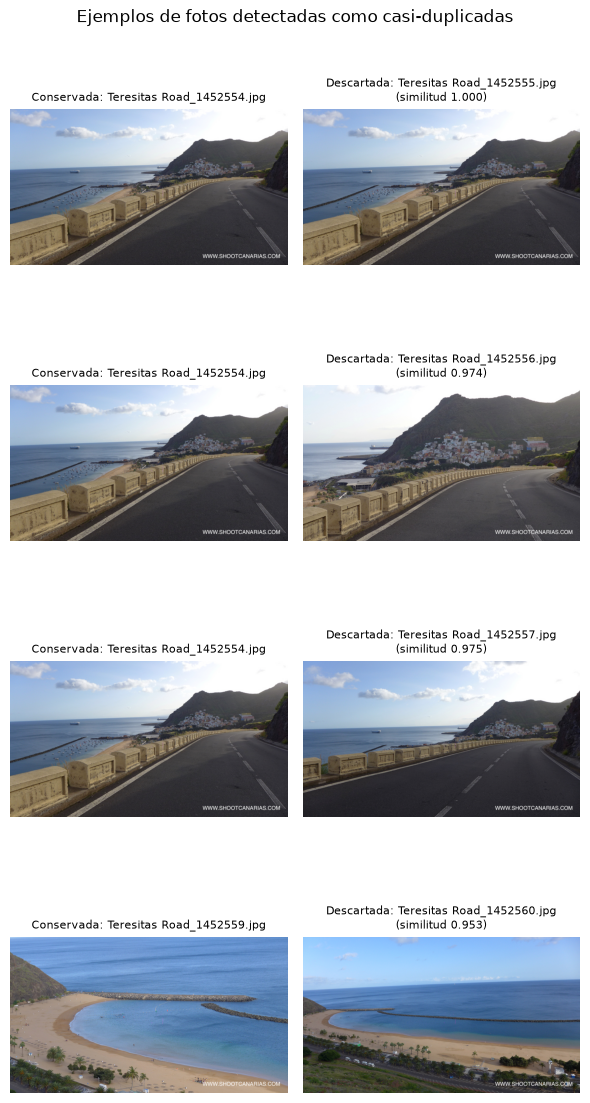

In [90]:
# Muestra algunos ejemplos de pares detectados como casi-duplicados, para validar el umbral a ojo
n_examples = min(4, len(duplicate_of))

if n_examples == 0:
    print("No se han encontrado fotos casi-duplicadas con este umbral.")
else:
    fig, axes = plt.subplots(n_examples, 2, figsize=(6, n_examples * 3))
    if n_examples == 1:
        axes = axes.reshape(1, 2)

    for row, (dup_name, (orig_name, sim)) in zip(axes, list(duplicate_of.items())[:n_examples]):
        row[0].imshow(load_normalized(LOCATION_DIR / orig_name))
        row[0].set_title(f"Conservada: {orig_name}", fontsize=8)
        row[0].axis("off")

        row[1].imshow(load_normalized(LOCATION_DIR / dup_name))
        row[1].set_title(f"Descartada: {dup_name}\n(similitud {sim:.3f})", fontsize=8)
        row[1].axis("off")

    fig.suptitle("Ejemplos de fotos detectadas como casi-duplicadas")
    plt.tight_layout()
    plt.show()

## 5. Clustering dinámico

No sabemos de antemano cuántos "ambientes" distintos tiene una localización, así que no podemos fijar un número de grupos. Usamos **HDBSCAN**, un algoritmo de clustering basado en densidad que decide él mismo cuántos grupos hay — y puede dejar fotos sin asignar a ningún grupo si son visualmente únicas, en vez de forzarlas a encajar en uno.

Reutilizamos los vectores ya normalizados (unitarios) de la deduplicación: con vectores unitarios, distancia euclídea y similitud coseno son equivalentes, así que no hace falta recalcular nada.

`MIN_CLUSTER_SIZE` es el segundo parámetro clave del notebook: cuanto más bajo, más grupos pequeños es capaz de detectar el algoritmo (y menos fotos quedan "sueltas").

In [91]:
MIN_CLUSTER_SIZE = 2  # tamaño mínimo de un grupo; súbelo si salen demasiados grupos pequeños

# cluster_selection_method="leaf" favorece grupos más finos y numerosos frente al
# comportamiento por defecto de HDBSCAN, que tiende a fusionar todo en pocos grupos grandes
# cuando las fotos son visualmente homogéneas (mismo edificio, misma luz).
clusterer = HDBSCAN(min_cluster_size=MIN_CLUSTER_SIZE, cluster_selection_method="leaf")
labels = clusterer.fit_predict(X_kept)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = int(np.sum(labels == -1))

print(f"{n_clusters} grupos visuales detectados, {n_noise} fotos sin grupo claro (ambientes únicos)")
for lbl in sorted(set(labels)):
    count = int(np.sum(labels == lbl))
    tag = "sin grupo (ambiente único)" if lbl == -1 else f"grupo {lbl}"
    print(f"  {tag}: {count} fotos")

7 grupos visuales detectados, 7 fotos sin grupo claro (ambientes únicos)
  sin grupo (ambiente único): 7 fotos
  grupo 0: 2 fotos
  grupo 1: 2 fotos
  grupo 2: 4 fotos
  grupo 3: 4 fotos
  grupo 4: 2 fotos
  grupo 5: 2 fotos
  grupo 6: 3 fotos


c:\Users\pablo\OneDrive - Wise Digital Partners SL\Documents\PoC tratamiento de escenarios\.venv\Lib\site-packages\sklearn\cluster\_hdbscan\hdbscan.py:722: FutureWarning: The default value of `copy` will change from False to True in 1.10. Explicitly set a value for `copy` to silence this warning.
  warn(


## 6. Selección de la foto representativa por grupo (medoid)

Para cada grupo, calculamos su centroide (el vector "promedio" del grupo) y elegimos la foto cuyo embedding esté más cerca de ese centroide — el ***medoid***. Es la foto que mejor representa a ese grupo, porque es la más "típica" dentro de él.

Las fotos que quedaron sin grupo en el paso anterior se tratan como su propio grupo de una sola foto: representan un ambiente visualmente único de la localización, así que se incluyen tal cual entre las representativas.

In [92]:
representative_indices = []

for lbl in sorted(set(labels)):
    idxs = np.where(labels == lbl)[0]
    if lbl == -1:
        representative_indices.extend(idxs.tolist())
        continue
    cluster_vecs = X_kept[idxs]
    centroid = cluster_vecs.mean(axis=0)
    centroid /= np.linalg.norm(centroid)
    sims_to_centroid = cluster_vecs @ centroid
    medoid_idx = idxs[np.argmax(sims_to_centroid)]
    representative_indices.append(int(medoid_idx))

representative_names = [kept_names[i] for i in representative_indices]
print(
    f"{len(representative_names)} fotos representativas de {len(kept_names)} únicas "
    f"({len(image_paths)} originales)"
)

14 fotos representativas de 26 únicas (81 originales)


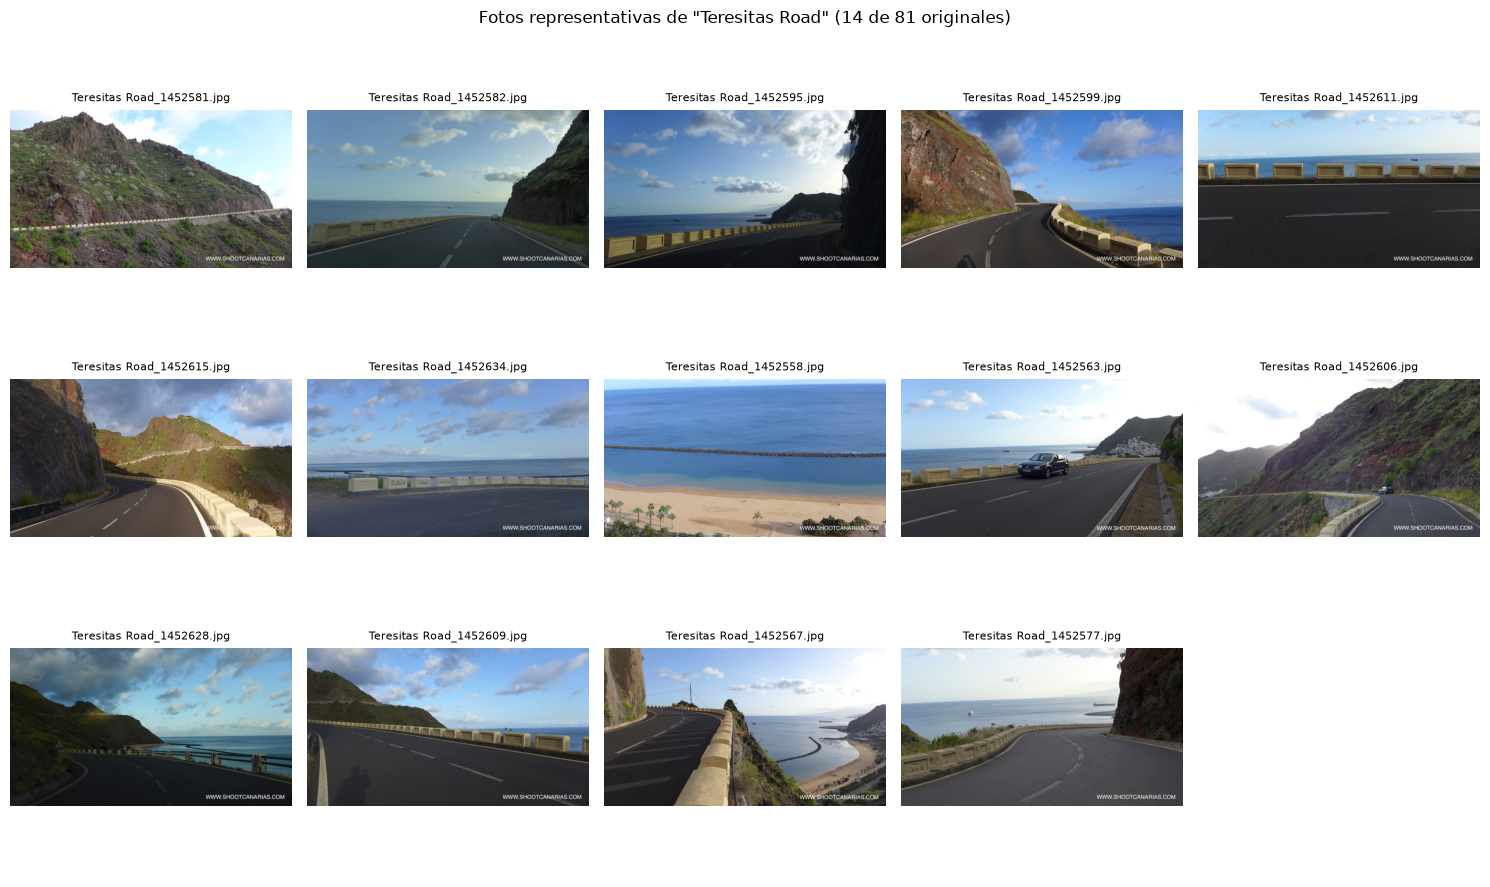

In [93]:
N_COLS = 5
n_rows = -(-len(representative_names) // N_COLS)  # división redondeando hacia arriba

fig, axes = plt.subplots(n_rows, N_COLS, figsize=(N_COLS * 3, n_rows * 3))
axes = np.array(axes).reshape(n_rows, N_COLS)

for ax, name in zip(axes.flat, representative_names):
    ax.imshow(load_normalized(LOCATION_DIR / name))
    ax.set_title(name, fontsize=8)
    ax.axis("off")

for ax in axes.flat[len(representative_names):]:
    ax.axis("off")

fig.suptitle(f'Fotos representativas de "{LOCATION_NAME}" ({len(representative_names)} de {len(image_paths)} originales)')
plt.tight_layout()
plt.show()

## 7. Descripción automática de la localización

Azure OpenAI limita a **10 imágenes por llamada** al chat con visión, y el número de fotos representativas varía según la localización (aquí, 28). Para no perder información ni tener que descartar representativas, seguimos un patrón *map-reduce*:

1. **Map** — repartimos las representativas en lotes de hasta 10 fotos. Cada lote se manda a gpt-4o de forma **independiente** (sin ver lo que dijeron los lotes anteriores) pidiendo observaciones técnicas en crudo, no una descripción final. Independizar los lotes evita que uno "arrastre" o repita lo que dijo el anterior en vez de describir objetivamente sus propias fotos.
2. **Reduce** — una única llamada final, solo de texto, recibe las notas de todos los lotes juntas y redacta la descripción definitiva para el dossier, sin repeticiones ni contradicciones entre lotes.

Los dos prompts (el de cada lote y el de síntesis final) están en una celda propia más abajo para poder ajustarlos sin tocar la lógica del pipeline.

In [94]:
def encode_image_b64(path: Path) -> str:
    """Codifica una foto (ya normalizada) en base64 para incluirla en un mensaje de chat."""
    img = load_normalized(path)
    buf = io.BytesIO()
    img.save(buf, format="JPEG", quality=85)
    return base64.b64encode(buf.getvalue()).decode()


def call_gpt4o(content, step: str = "(sin etiquetar)", max_tokens: int = 700) -> str:
    """Llama al chat de gpt-4o con un `content` de mensaje (texto y/o imágenes) y devuelve la respuesta.

    `step` es solo una etiqueta para el seguimiento de uso/coste (usage_log), no afecta a la llamada.
    """
    url = f"{OPENAI_ENDPOINT}/openai/deployments/{OPENAI_DEPLOYMENT}/chat/completions"
    params = {"api-version": OPENAI_API_VERSION}
    headers = {"api-key": AZURE_AI_KEY, "Content-Type": "application/json"}
    body = {"messages": [{"role": "user", "content": content}], "max_tokens": max_tokens}

    resp = requests.post(url, params=params, headers=headers, json=body)
    resp.raise_for_status()
    data = resp.json()
    log_openai_call(step, data.get("usage", {}))
    return data["choices"][0]["message"]["content"]

### Prompts (editables)

Esta celda es la única que hace falta tocar para ajustar el tono o el contenido de la descripción — el resto del pipeline no depende de cómo estén redactados estos textos.

- `BATCH_PROMPT` se envía junto con las fotos de cada lote — pide observaciones "en crudo", no una descripción pulida.
- `SYNTHESIS_PROMPT` se envía una sola vez, sin imágenes, con las notas de todos los lotes ya concatenadas (`{notes}`) y el nombre de la localización (`{location_name}`) — pide la descripción final para el dossier.

In [95]:
# --- Prompt para cada lote de fotos (máx. 10 imágenes, notas "en crudo") ---
BATCH_PROMPT = (
    "Eres un location scout profesional para producciones de publicidad y moda. "
    "Estas fotos muestran distintos ambientes o rincones representativos de UNA misma localización. "
    'El objetivo final es alimentar un buscador semántico: alguien escribirá consultas como '
    '"escenario salvaje con vegetación exuberante y luz natural" o "casa minimalista con grandes '
    'ventanales al mar", y tus notas deben capturar el tipo de detalle que permite encontrar esta '
    "localización con ese tipo de búsquedas.\n\n"
    "Redacta en español una lista breve de observaciones concretas y objetivas sobre lo que ves en "
    "ESTAS fotos: estilo arquitectónico y decorativo (p. ej. minimalista, rústico, industrial, "
    "mediterráneo, salvaje...), tipo y calidad de la luz natural, materiales y texturas predominantes, "
    "entorno o vistas (mar, montaña, vegetación, jardín, ciudad...), y características espaciales "
    "(tamaño de las estancias, altura de techos, tamaño de las ventanas). "
    "No redactes todavía una descripción final: son notas de trabajo para un resumen posterior."
)

# --- Prompt de síntesis final (solo texto, se ejecuta una única vez) ---
SYNTHESIS_PROMPT = (
    'Estás redactando la ficha descriptiva de una localización de fotografía/vídeo llamada '
    '"{location_name}", pensada para un motor de búsqueda semántico dentro de una aplicación de '
    "casting de localizaciones. El texto que generes se convertirá en un embedding, y los usuarios "
    "encontrarán esta localización cuando su búsqueda en lenguaje natural sea semánticamente "
    'parecida a tu descripción — por ejemplo: "escenario salvaje con vegetación exuberante y luz '
    'natural" o "casa de corte minimalista con estancias luminosas y grandes ventanales al mar".\n\n'
    "A partir de las notas técnicas de abajo (tomadas sobre distintos grupos de fotos de esta misma "
    "localización), redacta en español una descripción de un único párrafo, concreta y rica en "
    "vocabulario descriptivo y sensorial: estilo arquitectónico y decorativo, tipo y calidad de la "
    "luz, materiales y texturas, entorno natural o vistas, y características espaciales (tamaño de "
    'las estancias, ventanas, techos). Evita adjetivos vacíos de marketing ("único", "inolvidable", '
    '"espectacular") que no aportan información distintiva para la búsqueda; prioriza términos '
    "concretos y descriptivos frente a los superlativos. No repitas información entre distintas "
    "partes del texto. Entre 80 y 150 palabras.\n\nNotas:\n{notes}"
)

In [96]:
MAX_IMAGES_PER_CALL = 10  # límite de Azure OpenAI, no tocar

batches = [
    representative_names[i : i + MAX_IMAGES_PER_CALL]
    for i in range(0, len(representative_names), MAX_IMAGES_PER_CALL)
]
print(f"{len(representative_names)} fotos representativas repartidas en {len(batches)} lote(s)")

batch_notes = []
for i, batch in enumerate(batches, start=1):
    content = [{"type": "text", "text": BATCH_PROMPT}]
    for name in batch:
        b64 = encode_image_b64(LOCATION_DIR / name)
        content.append({"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}})

    notes = call_gpt4o(content, step=f"7a. Lote {i}/{len(batches)}")
    batch_notes.append(notes)
    print(f"Lote {i}/{len(batches)} ({len(batch)} fotos) procesado.")

14 fotos representativas repartidas en 2 lote(s)
    [7a. Lote 1/2] 3714 tokens entrada + 348 salida -> $0.0056
Lote 1/2 (10 fotos) procesado.
    [7a. Lote 2/2] 1620 tokens entrada + 277 salida -> $0.0030
Lote 2/2 (4 fotos) procesado.


In [97]:
display(Markdown(batch_notes[1]))

1. **Estilo**: Carretera de montaña con atmósfera natural y salvaje. Elementos funcionales en el diseño como barandillas y curvas que complementan el paisaje.

2. **Entorno y vistas**: Entorno costero con vistas panorámicas al océano, formaciones montañosas al fondo, acantilados y áreas de vegetación dispersa. La carretera bordea la línea de costa, ofreciendo perspectivas amplias.

3. **Luz natural**: Luz diurna suave, cambiando entre cielos parcialmente nublados e iluminaciones directas. La orientación genera contrastes entre zonas de luz y sombra.

4. **Materiales y texturas**: Asfalto oscuro en la carretera, barandillas de piedra o cemento en tonos claros desgastados, roca natural de color marrón y vegetación limitada en las paredes del acantilado.

5. **Características espaciales**: Carretera asfaltada de doble sentido con dimensiones moderadas, sinuosa, con curvas que generan dinamismo visual. Espacio abierto con horizonte amplio y sensación de profundidad.

6. **Ambiente**: Predominio del cielo y el océano en la composición, lo que confiere un carácter relajante y a la vez aventurero, acentuado por el contraste de las montañas y el mar.

In [98]:
from IPython.display import Markdown, display

combined_notes = "\n\n---\n\n".join(f"[Lote {i}]\n{notes}" for i, notes in enumerate(batch_notes, start=1))
synthesis_content = SYNTHESIS_PROMPT.format(location_name=LOCATION_NAME, notes=combined_notes)

final_description = call_gpt4o(synthesis_content, step="7b. Síntesis final", max_tokens=500)

display(Markdown(f"### Descripción generada — {LOCATION_NAME}\n\n{final_description}"))

    [7b. Síntesis final] 914 tokens entrada + 226 salida -> $0.0020


### Descripción generada — Teresitas Road

"Teresitas Road es una sinuosa carretera de montaña que serpentea a lo largo de un entorno costero, fusionando paisajes naturales y funcionalidad estructural. El trazado asfaltado de doble carril, delimitado por barandas bajas en concreto claro, presenta curvas pronunciadas y pendientes moderadas, generando una estética dinámica y envolvente. Las superficies del entorno combinan texturas ásperas de roca natural, en tonos marrones, rojizos y verdes cubiertos parcialmente por matorrales, con el oscuro asfalto que contrasta visualmente. La luz natural varía a lo largo del día, con momentos de intensa iluminación diurna y juegos de sombra proyectados por acantilados y vegetación dispersa. Las vistas, de horizonte amplio y despejado, abarcan el océano brillante, una playa de arena dorada con palmeras y, a lo lejos, pequeños edificios blancos costeros integrados con el paisaje. El espacio sugiere amplitud serena, realzada por el cielo y el contraste entre la elevación de la carretera y el mar más abajo."

## 8. Resumen de uso y coste

Agregado de todas las llamadas a Azure registradas en esta ejecución del notebook (vectorizaciones de imagen + llamadas a gpt-4o).

In [99]:
usage_summary()

Azure Vision  — 81 imágenes vectorizadas -> $0.0081
Azure OpenAI  — 3 llamadas, 6248 tokens entrada + 851 tokens salida -> $0.0106
TOTAL estimado: $0.0187
